<a href="https://colab.research.google.com/github/nehasingh913833-gif/basic-ML/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Retail_Transactions_2000.csv to Retail_Transactions_2000.csv
User uploaded file "Retail_Transactions_2000.csv" with length 133707 bytes


loading data exporting libs

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


sns.set(style="whitegrid")




df = pd.read_csv('Retail_Transactions_2000.csv')













Visualisation

In [ ]:
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Checking for Null Values ---")
print(df.isnull().sum())

print("\n--- Checking for Duplicated Rows ---")
print(f"Number of duplicated rows: {df.duplicated().sum()}")
print("-" * 40 + "\n")


--- First 5 Rows ---
  TransactionID CustomerID  Gender  Age       City ProductCategory  Quantity  \
0        T00001      C2824  Female   33  Bengaluru         Fashion         3   
1        T00002      C1409   Other   20       Pune           Books         5   
2        T00003      C5506   Other   47       Pune       Furniture         1   
3        T00004      C5012   Other   21  Hyderabad       Groceries         5   
4        T00005      C4657  Female   41    Chennai          Sports         1   

   Price PurchaseDate PaymentMode  TotalAmount  
0   4479   2023-03-15        Cash        13437  
1   1051   2023-01-22        Card         5255  
2    111   2023-04-18      Wallet          111  
3   2946   2023-08-09        Cash        14730  
4   3123   2023-09-23      Wallet         3123  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           ----------

cleaning data

In [ ]:
print(f"Shape before outlier removal: {df.shape}")


def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

outlier_columns = ['Age', 'Quantity', 'Price']
for col in outlier_columns:
    df = remove_outliers(df, col)

print(f"Shape after outlier removal: {df.shape}")


df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])


df['PurchaseMonth'] = df['PurchaseDate'].dt.month

Shape before outlier removal: (2000, 11)
Shape after outlier removal: (2000, 11)


In [ ]:
age_bins = [18, 30, 40, 50, 60, 71]
age_labels = ['18-30', '31-40', '41-50', '51-60', '61-70']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

print("\n--- DataFrame after Feature Engineering (first 5 rows) ---")
print(df.head())


df_original_cleaned = df.copy()

df_processed = df.drop(columns=['TransactionID', 'CustomerID', 'PurchaseDate'])
print("\nDropped 'TransactionID', 'CustomerID', and 'PurchaseDate' columns.")
print("-" * 40 + "\n")



--- DataFrame after Feature Engineering (first 5 rows) ---
  TransactionID CustomerID  Gender  Age       City ProductCategory  Quantity  \
0        T00001      C2824  Female   33  Bengaluru         Fashion         3   
1        T00002      C1409   Other   20       Pune           Books         5   
2        T00003      C5506   Other   47       Pune       Furniture         1   
3        T00004      C5012   Other   21  Hyderabad       Groceries         5   
4        T00005      C4657  Female   41    Chennai          Sports         1   

   Price PurchaseDate PaymentMode  TotalAmount  PurchaseMonth AgeGroup  
0   4479   2023-03-15        Cash        13437              3    31-40  
1   1051   2023-01-22        Card         5255              1    18-30  
2    111   2023-04-18      Wallet          111              4    41-50  
3   2946   2023-08-09        Cash        14730              8    18-30  
4   3123   2023-09-23      Wallet         3123              9    41-50  

Dropped 'Transaction

dimentionality reduction using pca

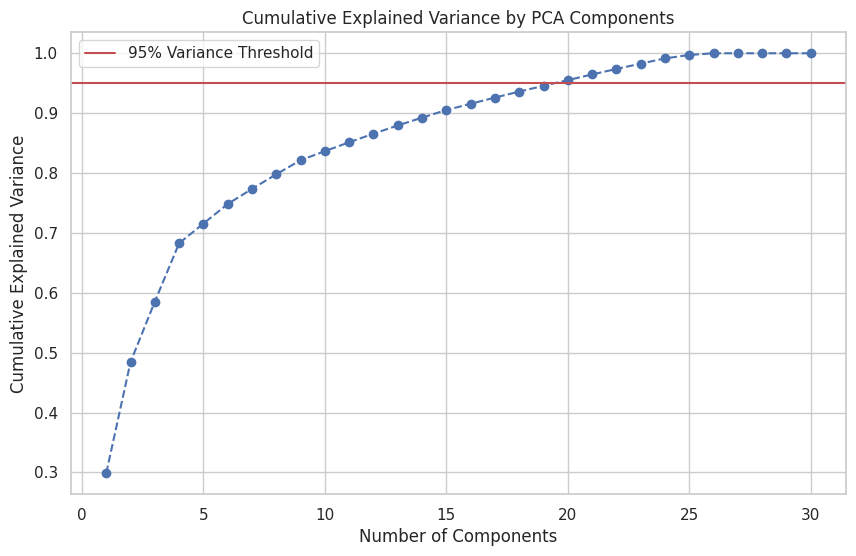

Optimal number of components to retain 95% variance: 20
Data transformed using PCA. New shape: (2000, 20)
----------------------------------------



In [ ]:
pca_full = PCA()
pca_full.fit(X_processed)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.legend()
plt.grid(True)
plt.show()


n_components_optimal = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Optimal number of components to retain 95% variance: {n_components_optimal}")


pca = PCA(n_components=n_components_optimal)
X_pca = pca.fit_transform(X_processed)
print(f"Data transformed using PCA. New shape: {X_pca.shape}")
print("-" * 40 + "\n")

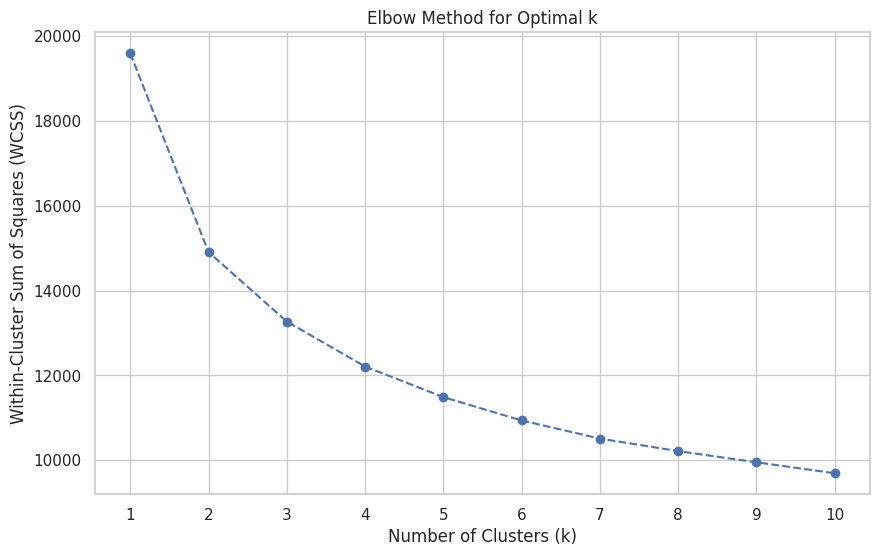

Based on the Elbow Method, the optimal number of clusters is chosen to be: 4
Cluster labels have been added to the cleaned dataset.
----------------------------------------



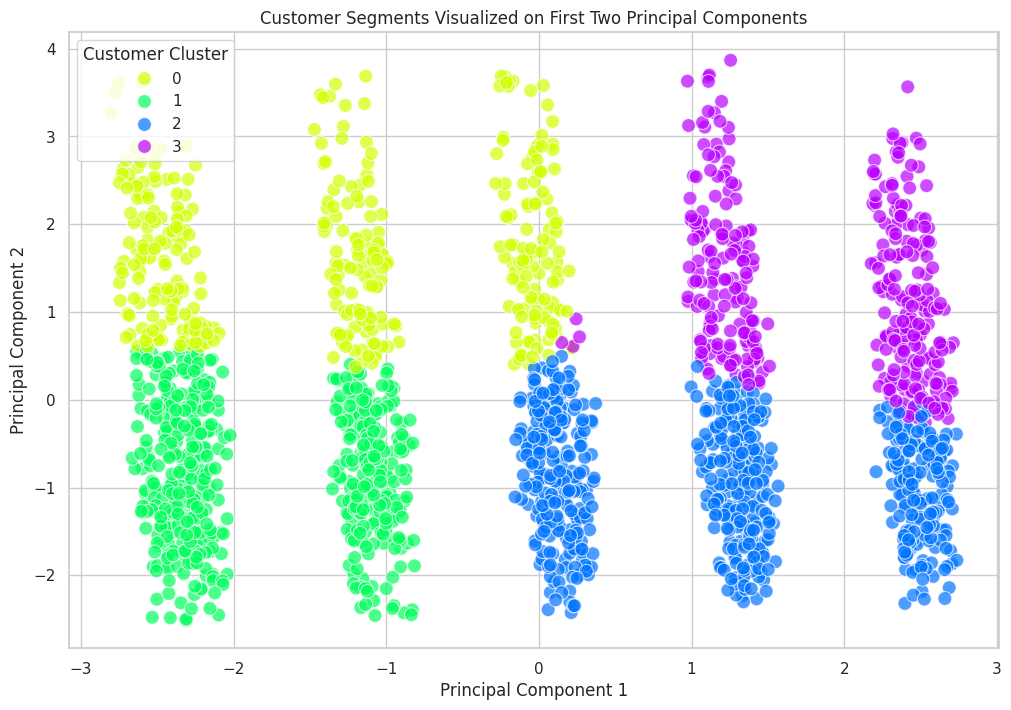

  TransactionID CustomerID  Gender  Age       City ProductCategory  Quantity  \
0        T00001      C2824  Female   33  Bengaluru         Fashion         3   
1        T00002      C1409   Other   20       Pune           Books         5   
2        T00003      C5506   Other   47       Pune       Furniture         1   
3        T00004      C5012   Other   21  Hyderabad       Groceries         5   
4        T00005      C4657  Female   41    Chennai          Sports         1   
5        T00006      C3286    Male   63      Delhi       Furniture         2   
6        T00007      C2679   Other   30       Pune     Electronics         5   
7        T00008      C9935  Female   35  Hyderabad           Books         5   
8        T00009      C2424  Female   41     Jaipur           Books         5   
9        T00010      C7912    Male   70    Lucknow       Groceries         1   

   Price PurchaseDate PaymentMode  TotalAmount  PurchaseMonth AgeGroup  \
0   4479   2023-03-15        Cash        1343

In [ ]:
wcss = []
k_range = range(1, 11)
for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


optimal_k = 4
print(f"Based on the Elbow Method, the optimal number of clusters is chosen to be: {optimal_k}")


kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)


df_original_cleaned['Cluster'] = cluster_labels
print("Cluster labels have been added to the cleaned dataset.")
print("-" * 40 + "\n")




df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_optimal)])
df_pca['Cluster'] = cluster_labels


plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette=sns.color_palette("hsv", n_colors=optimal_k),
    s=100,
    alpha=0.7
)
plt.title('Customer Segments Visualized on First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Cluster')
plt.grid(True)
plt.show()



print(df_original_cleaned.head(10))


print(df_original_cleaned['Cluster'].value_counts())